# Pillow: Zillow for Pune

## Problem Statement
Lack of trust in users due to inconsistent pricing in similar areas.
Since Pillow is a two-sided marketplace where users can upload a listing of the property they want to sell and users can also browse the property catalog to see the properties they want to rent or buy, trust needs to be built on both sides:

1. **Supply Side**:
   - Needs answer to the question: “Why is my listing not getting traction”
   - Build a price regulation model so that when a vendor adds a listing, the model returns a range for the listing price. This prevents the vendors from overpricing or underpricing the listing
2. **Demand Side**:
    - Build SHAP explainability to answer "Why are two properties in the same area different?"

# Import Packages

In [ ]:
!uv pip install pandas numpy matplotlib seaborn scikit-learn xgboost shap openpyxl itables jinja2 seaborn plotly nbformat nltk
%pip install pandas numpy matplotlib seaborn scikit-learn xgboost shap openpyxl itables jinja2 seaborn plotly nbformat nltk

Audited 14 packages in 20ms
Note: you may need to restart the kernel to use updated packages.


In [1006]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
import xgboost as xgb
import shap
import re
import warnings
from itables import show as _show
import itables.options as opt

warnings.filterwarnings('ignore')

np.random.seed(10)

# Load Data

In [1007]:
# Load the dataset
df = pd.read_excel('Pune_Real_Estate_Data.xlsx')
print(f"Dataset shape: {df.shape}")
print(f"\nData types:")
print(df.dtypes)
print(f"\nMissing values:")
print(df.isnull().sum())

Dataset shape: (200, 18)

Data types:
Sr. No.                               int64
Location                                str
Sub-Area                                str
Propert Type                            str
Property Area in Sq. Ft.             object
Price in lakhs                       object
Price in Millions                   float64
Company Name                            str
TownShip Name/ Society Name             str
Total TownShip Area in Acres        float64
ClubHouse                               str
School / University in Township         str
Hospital in TownShip                    str
Mall in TownShip                        str
Park / Jogging track                    str
Swimming Pool                           str
Gym                                     str
Description                             str
dtype: object

Missing values:
Sr. No.                               0
Location                              0
Sub-Area                              0
Propert Type       

In [1008]:
# Rename all columns to snake_case
df = df.rename(columns={
      'Sr. No.': 'sr_no',
      'Location': 'location',
      'Sub-Area': 'sub_area',
      'Propert Type': 'property_type',
      'Property Area in Sq. Ft.': 'property_area_in_sq_ft',
      'Price in lakhs': 'price_in_lakhs',
      'Price in Millions': 'price_in_millions',
      'Company Name': 'company_name',
      'TownShip Name/ Society Name': 'township_name_society_name',
      'Total TownShip Area in Acres': 'total_township_area_in_acres',
      'ClubHouse': 'clubhouse',
      'School / University in Township ': 'school_university_in_township',
      'Hospital in TownShip': 'hospital_in_township',
      'Mall in TownShip': 'mall_in_township',
      'Park / Jogging track': 'park_jogging_track',
      'Swimming Pool': 'swimming_pool',
      'Gym': 'gym',
      'Description': 'description'
  })

print("Renamed columns:")
print(df.columns.tolist())

# aligning for pretty print
def show(df, **kwargs):
      styled = df.style.set_properties(**{'text-align': 'center'})
      if 'description' in df.columns:
          styled = styled.set_properties(subset=['description'], **{'text-align': 'left'})
      _show(styled, allow_html=True, **kwargs)

Renamed columns:
['sr_no', 'location', 'sub_area', 'property_type', 'property_area_in_sq_ft', 'price_in_lakhs', 'price_in_millions', 'company_name', 'township_name_society_name', 'total_township_area_in_acres', 'clubhouse', 'school_university_in_township', 'hospital_in_township', 'mall_in_township', 'park_jogging_track', 'swimming_pool', 'gym', 'description']


In [1009]:
# Drop redundant columns
columns_to_drop = [
      'sr_no',                           # Just a row index, not useful
      'price_in_millions',               # Same as price_in_lakhs (same data, different units)
      'location'                         # Low variance, Single value across all rows ("Pune, Maharashtra, India")
  ]

df = df.drop(columns=columns_to_drop, errors='ignore')
df.columns

Index(['sub_area', 'property_type', 'property_area_in_sq_ft', 'price_in_lakhs',
       'company_name', 'township_name_society_name',
       'total_township_area_in_acres', 'clubhouse',
       'school_university_in_township', 'hospital_in_township',
       'mall_in_township', 'park_jogging_track', 'swimming_pool', 'gym',
       'description'],
      dtype='str')

# EDA

### Target Variable: Price in lakhs

In [1010]:
# nulls

# 1. Print datatype of the 'price_in_lakhs' column
print("Datatype of 'price_in_lakhs':", df['price_in_lakhs'].dtype)

# Check for 'Null' strings as well as actual nulls
null_or_Null_mask = df['price_in_lakhs'].isnull() | (df['price_in_lakhs'].astype(str).str.strip().str.lower() == 'null')
num_null_or_Null = null_or_Null_mask.sum()
print("Number of rows where 'price_in_lakhs' is null or 'Null':", num_null_or_Null)

if num_null_or_Null > 0:
    print("Records with null or 'Null' in 'price_in_lakhs':")
    display(df[null_or_Null_mask])
else:
    print("No null or 'Null' records found in 'price_in_lakhs'.")



Datatype of 'price_in_lakhs': object
Number of rows where 'price_in_lakhs' is null or 'Null': 1
Records with null or 'Null' in 'price_in_lakhs':


,sub_area,property_type,property_area_in_sq_ft,price_in_lakhs,company_name,township_name_society_name,total_township_area_in_acres,clubhouse,school_university_in_township,hospital_in_township,mall_in_township,park_jogging_track,swimming_pool,gym,description
41,Keshav Nagar,3BHK,1272 to 2138,Null,Mantra Properties,Mantra Insignia,NaN,Yes,No,No,No,Yes,Yes,Yes,"Mantra insignia is surrounded by nautre, the p..."


In [1011]:
# Print rows where sub_area is 'keshav nagar' (case-insensitive, trimmed)
df_keshav_nagar = df[df['sub_area'].astype(str).str.strip().str.lower() == 'keshav nagar']
show(df_keshav_nagar)

Loading ITables v2.7.3 from the internet... (need help?)


There is a null price row in the Keshav Nagar subset. We can train a linear regression model to predict the price of the null row based on the 2 existing rows in Keshav Nagar.

In [1012]:
from sklearn.linear_model import LinearRegression
import re

# Helper function to extract numeric area (handle ranges like "801 to 1125")
def extract_area(area_str):
    if pd.isna(area_str):
        return np.nan
    area_str = str(area_str).strip()
    if 'to' in area_str.lower():
        parts = re.findall(r'\d+', area_str)
        if len(parts) == 2:
            return (int(parts[0]) + int(parts[1])) / 2
    try:
        return float(re.findall(r'\d+', area_str)[0])
    except:
        return np.nan

def extract_price(price_str):
    if pd.isna(price_str) or price_str == 'Null':
        return np.nan
    try:
        return float(price_str)
    except:
        return np.nan

# Start fresh from original df (keep the null row)
df_clean = df.copy()

# Filter to Keshav Nagar
keshav = df_clean[df_clean['sub_area'] == 'Keshav Nagar'].copy()
keshav['area_numeric'] = keshav['property_area_in_sq_ft'].apply(extract_area)
keshav['price_numeric'] = keshav['price_in_lakhs'].apply(extract_price)

print("Keshav Nagar properties:")
show(keshav[['property_type', 'property_area_in_sq_ft', 'price_in_lakhs', 'area_numeric',
'price_numeric']])

# Fit on rows WITH prices
keshav_train = keshav[keshav['price_numeric'].notna()]
X = keshav_train[['area_numeric']].values
y = keshav_train['price_numeric'].values

model = LinearRegression()
model.fit(X, y)

# Predict for null row
null_row = keshav[keshav['price_numeric'].isna()]
if len(null_row) > 0:
    X_pred = null_row[['area_numeric']].values
    predicted_price = model.predict(X_pred)[0]
    print(f"\nModel: price = {model.intercept_:.2f} + {model.coef_[0]:.4f} * area")
    print(f"Predicted price for {null_row['property_type'].values[0]}({null_row['area_numeric'].values[0]:.0f} sq ft): {predicted_price:.2f} lakhs")
else:
    print("No null rows found in Keshav Nagar")

Keshav Nagar properties:


Loading ITables v2.7.3 from the internet... (need help?)



Model: price = 22.61 + 0.0357 * area
Predicted price for 3BHK(1705 sq ft): 83.50 lakhs


In [1013]:
# Plotting the regression line for Keshav Nagar
import plotly.graph_objects as go
import re
from sklearn.linear_model import LinearRegression

# Extract training data from Keshav Nagar
keshav = df[df['sub_area'] == 'Keshav Nagar'].copy()
keshav_train = keshav[keshav['price_in_lakhs'] != 'Null']

# Convert area ranges to midpoints
X_corrected = []
for area in keshav_train['property_area_in_sq_ft']:
    nums = [int(x) for x in re.findall(r'\d+', str(area))]
    X_corrected.append(sum(nums) / len(nums))
X_train = [[x] for x in X_corrected]
y_train = keshav_train['price_in_lakhs'].astype(float).values

# Fit model
model = LinearRegression().fit(X_train, y_train)

# Predict for 3BHK (1705 sq ft midpoint of 1272-2138)
null_area_midpoint = 1705
predicted = model.predict([[null_area_midpoint]])[0]

# Plot
fig = go.Figure()

fig.add_trace(go.Scatter(x=[x[0] for x in X_train], y=y_train, mode='markers+text',
                        marker=dict(size=10, color='blue'),
                        text=['1BHK', '2BHK'], textposition='top center',
                        name='Training'))

fig.add_trace(go.Scatter(x=[null_area_midpoint], y=[predicted], mode='markers+text',
                        marker=dict(size=10, color='red'),
                        text=[f'3BHK: {predicted:.2f}L'], textposition='top center',
                        name='Predicted'))

x_line = [500, 1800]
y_line = model.predict([[500], [1800]])
fig.add_trace(go.Scatter(x=x_line, y=y_line, mode='lines',
                        line=dict(color='gray', dash='dash'),
                        name='LR fit'))

fig.update_layout(title='Keshav Nagar: Price vs Area',
                xaxis_title='Area (sq ft)', yaxis_title='Price (lakhs)',
                hovermode='closest', height=500, width=700)
fig.show()

In [1014]:
# Fill the predicted price
df_clean.loc[(df_clean['sub_area'] == 'Keshav Nagar') &
            (df_clean['property_type'] == '3BHK') &
            (df_clean['price_in_lakhs'] == 'Null'), 'price_in_lakhs'] = 83.50

# Verify
print(df_clean[df_clean['sub_area'] == 'Keshav Nagar'][['property_type',
'property_area_in_sq_ft', 'price_in_lakhs']])

df = df_clean.copy()

   property_type property_area_in_sq_ft price_in_lakhs
39          1BHK                    543             42
40          2BHK            801 to 1125             57
41          3BHK           1272 to 2138           83.5


In [1015]:
df['price_in_lakhs'] = df['price_in_lakhs'].astype(float).round(2)
# show(df[['price_in_lakhs']])

Let's see where our imputed point sits in the data

In [1016]:
import plotly.graph_objects as go

col_type = 'property_type'   # replace if different
col_price = 'price_in_lakhs' # replace if different

def normalize_type(s):
    return str(s).upper().replace(' ', '')

df['_type_norm'] = df[col_type].apply(normalize_type)

groups = {'1BHK': 'blue', '2BHK': 'green', '3BHK': 'red'}

fig = go.Figure()

# Grey for everything else
others = df[~df['_type_norm'].isin(groups.keys())]
fig.add_trace(go.Scatter(x=others.index, y=others[col_price], mode='markers',
                        marker=dict(color='grey', size=7), name='Other'))

# BHK groups
for bhk, color in groups.items():
    subset = df[df['_type_norm'] == bhk]
    fig.add_trace(go.Scatter(x=subset.index, y=subset[col_price], mode='markers',
                            marker=dict(color=color, size=7), name=bhk))

# Imputed point in black
imputed = df[(df['_type_norm'] == '3BHK') & (df[col_price] == 83.5)]
fig.add_trace(go.Scatter(x=imputed.index, y=imputed[col_price], mode='markers',
                        marker=dict(color='black', size=12, symbol='star'),
                        name='Imputed 3BHK'))

fig.update_layout(title='Price Distribution by BHK Type',
                xaxis_title='Index', yaxis_title='Price (lakhs)',
                height=500, width=800)
fig.show()

df.drop(columns=['_type_norm'], inplace=True)

In [1017]:
# Outlier Analysis for target variable.

import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.stats import gaussian_kde

median_val = df['price_in_lakhs'].median()
mean_val = df['price_in_lakhs'].mean()

fig = make_subplots(rows=1, cols=2, subplot_titles=('Boxplot with Data Points',
'Distribution'),
                    horizontal_spacing=0.12, specs=[[{}, {'secondary_y': True}]])

# Boxplot with all points
fig.add_trace(
    go.Box(x=df['price_in_lakhs'], name='Price', boxpoints='all',
            pointpos=0, jitter=0.3,
            marker=dict(opacity=0.5, size=5, color='#636EFA'),
            line=dict(color='#636EFA', width=2),
            fillcolor='rgba(99, 110, 250, 0.15)'),
    row=1, col=1
)

# Histogram
fig.add_trace(
    go.Histogram(x=df['price_in_lakhs'], nbinsx=30, name='Count',
                marker=dict(color='rgba(99, 110, 250, 0.6)',
                            line=dict(color='#636EFA', width=1))),
    row=1, col=2, secondary_y=False
)

# KDE curve
kde = gaussian_kde(df['price_in_lakhs'].dropna())
x_range = np.linspace(df['price_in_lakhs'].min(), df['price_in_lakhs'].max(), 200)
fig.add_trace(
    go.Scatter(x=x_range, y=kde(x_range), mode='lines', name='KDE',
                line=dict(color='#EF553B', width=2.5)),
    row=1, col=2, secondary_y=True
)

# Mean & Median lines
fig.add_vline(x=median_val, line=dict(color='#EF553B', dash='dash', width=2), row=1, col=2,
            annotation=dict(text=f'Median: {median_val:.0f}', font=dict(color='#EF553B',
size=12)))
fig.add_vline(x=mean_val, line=dict(color='#FFA15A', dash='dash', width=2), row=1, col=2,
            annotation=dict(text=f'Mean: {mean_val:.0f}', font=dict(color='#FFA15A',
size=12)))

fig.update_layout(
    autosize=True,
    showlegend=False,
    template='plotly_white',
    title=dict(text='Target Variable: Price in Lakhs', x=0.5, font=dict(size=18)),
    font=dict(family='Segoe UI', size=13),
    margin=dict(t=80, b=50, l=50, r=50),
)

fig.update_xaxes(title_text='Price in Lakhs', row=1, col=1, gridcolor='#eee')
fig.update_xaxes(title_text='Price in Lakhs', row=1, col=2, gridcolor='#eee')
fig.update_yaxes(title_text='Count', row=1, col=2, secondary_y=False, gridcolor='#eee')
fig.update_yaxes(showticklabels=False, row=1, col=2, secondary_y=True)

fig.show()


**Observations:**
  1. Right-skewed distribution with outliers at 400+ and ~900 lakhs — these are genuine premium properties, not data errors.
  2. Not removing outliers because: dropping them would cap the model's price range at ~200 lakhs, meaning premium listings would be priced like mid-range ones — breaking vendor trust (Pillow's core problem).
  3. Log transform (log1p) compresses the scale — e.g., 50→3.9 and 900→6.8 — so outliers don't dominate while still being represented. 
  4. Target encoding uses mean price per category. Without log transform, one 900 lakh property in an area inflates that area's encoded value. Encoding on log-transformed prices keeps the means stable.
  5. 900 lakhs is a lot of money for a 3 bhk property in Pune. The outliers needs to be studied more.

In [1018]:
high_price_rows = df[df['price_in_lakhs'] > 400]
show(high_price_rows)

Loading ITables v2.7.3 from the internet... (need help?)


930 lakhs (93 million) is way too much for a 3 bhk property in Pune. These numbers could be justified if the property area were correspondingly large. In this case , the 923 lakh property is 923 sq ft and the 930 lakh property is 930 sq ft. This looks like an error. We can run a linear regression model to predict the price of these property.

In [1019]:
# LR model to predict the price of these property.

# Check Nirman Developers subset
nirman = df[df['company_name'].str.lower() == 'nirman developers'].copy()
print(f"Nirman Developers rows: {len(nirman)}")
show(nirman[['property_type', 'property_area_in_sq_ft', 'price_in_lakhs']])

Nirman Developers rows: 6


Loading ITables v2.7.3 from the internet... (need help?)


LR model to predict the price of these property.

In [1020]:
nirman = df[df['company_name'].str.lower() == 'nirman developers'].copy()

# Training: non-3BHK rows (the 2BHK records)
train = nirman[nirman['property_type'].str.upper().str.replace(' ', '') != '3BHK']
X_train = train['property_area_in_sq_ft'].values.reshape(-1, 1)
y_train = train['price_in_lakhs'].values

# Rows to predict (the 923/930 outliers)
to_predict = nirman[nirman['property_type'].str.upper().str.replace(' ', '') == '3BHK']
X_pred = to_predict['property_area_in_sq_ft'].values.reshape(-1, 1)

model = LinearRegression().fit(X_train, y_train)
predicted_prices = model.predict(X_pred)

print("Predicted prices:")
for idx, price in zip(to_predict.index, predicted_prices):
    print(f"  Index {idx}: {price:.2f} lakhs")

Predicted prices:
  Index 73: 62.23 lakhs
  Index 74: 62.69 lakhs


In [1021]:
x_line = [train['property_area_in_sq_ft'].min() - 50,
to_predict['property_area_in_sq_ft'].max() + 50]
y_line = model.predict([[x] for x in x_line])

fig = go.Figure()

# Training points (blue)
fig.add_trace(go.Scatter(
    x=train['property_area_in_sq_ft'], y=y_train,
    mode='markers+text',
    marker=dict(color='blue', size=8),
    text=train['property_type'],
    textposition='top center',
    name='Training (2BHK)'
))

# Predicted points (red)
fig.add_trace(go.Scatter(
    x=to_predict['property_area_in_sq_ft'], y=predicted_prices,
    mode='markers+text',
    marker=dict(color='red', size=10),
    text=[f'{p:.2f}L' for p in predicted_prices],
    textposition='top center',
    name='Predicted (3BHK)'
))

# Regression line
fig.add_trace(go.Scatter(
    x=x_line, y=y_line,
    mode='lines',
    line=dict(color='gray', dash='dash'),
    name='LR fit'
))

fig.update_layout(title='Nirman Developers: Price vs Area',
                xaxis_title='Area (sq ft)', yaxis_title='Price (lakhs)',
                height=500, width=700)
fig.show()

In [1022]:
for idx, price in zip(to_predict.index, predicted_prices):
    df.loc[idx, 'price_in_lakhs'] = round(price, 2)

show(df)

Loading ITables v2.7.3 from the internet... (need help?)


## Property type

Extracts the number of bedrooms from the property_type column.
- Property type with + (e.g. 3+2 or 2+2): This follows an Indian real estate convention
where 3+2 BHK means 3 bedrooms + 2 servant quarters or utility rooms. It is not a true
5-bedroom unit, but it is larger than a standard 3-bedroom. The assumption made here is
that it falls between the main number and main+2, so we map it to main+1 (e.g. 3+2 → 4,
2+2 → 3).
- Commercial property — shop is dropped since it is an outlier wrt residential properties. In production commercial properties will have a separate model.
- Remove 'bhk', 'grand' and extract number (handles decimals too)

In [1023]:
def extract_bedrooms(val):
    s = re.sub(r'[a-zA-Z\s]', '', str(val).strip())
    if '+' in s:
        return float(s.split('+')[0]) + 1
    try:
        return float(s)
    except ValueError:
        return np.nan

df['no_of_bedrooms'] = df['property_type'].apply(extract_bedrooms)
df = df.drop(columns=['property_type'])
df = df.dropna(subset=['no_of_bedrooms'])

print(df.shape)
show(df)

(199, 15)


Loading ITables v2.7.3 from the internet... (need help?)


In [1024]:
fig = go.Figure()

for bedrooms in sorted(df['no_of_bedrooms'].unique()):
    subset = df[df['no_of_bedrooms'] == bedrooms]
    fig.add_trace(go.Box(
        y=subset['price_in_lakhs'],
        name=str(bedrooms),
        boxpoints='all',
        jitter=0.3,
        pointpos=0
    ))

fig.update_layout(
    title='Price Distribution by Number of Bedrooms',
    xaxis_title='No. of Bedrooms',
    yaxis_title='Price (lakhs)',
    height=500, width=800
)
fig.show()

The bulk of the properties are 2-3 bedroom properties. This aligns with the price distribution.

## Property in sq ft

In [1025]:
# Check for the spread in the property area in sq ft with range.
import re

ranges = [v for v in df['property_area_in_sq_ft'] if isinstance(v, str) and ('to' in v or ','
in v)]

for r in ranges:
    nums = [float(x) for x in re.findall(r'[\d.]+', r)]
    spread = nums[1] - nums[0]
    pct = (spread / nums[0]) * 100
    print(f"{r:>20} → spread: {spread:.0f} sqft ({pct:.1f}%)")

          877 to 912 → spread: 35 sqft (4.0%)
        1077 to 1272 → spread: 195 sqft (18.1%)
          662 to 845 → spread: 183 sqft (27.6%)
         890 to 1212 → spread: 322 sqft (36.2%)
          792 to 965 → spread: 173 sqft (21.8%)
         801 to 1125 → spread: 324 sqft (40.4%)
        1272 to 2138 → spread: 866 sqft (68.1%)
          624 to 761 → spread: 137 sqft (22.0%)
          561 to 902 → spread: 341 sqft (60.8%)
        1056 to 1091 → spread: 35 sqft (3.3%)
          1181, 1364 → spread: 183 sqft (15.5%)
        1070 to 1200 → spread: 130 sqft (12.1%)
        1300 to 1400 → spread: 100 sqft (7.7%)
         769 to 809  → spread: 40 sqft (5.2%)
        1101 to 1113 → spread: 12 sqft (1.1%)


- Only 14 out of 199 rows have ranges (7%)
- Spreads vary from 1% to 60%, but high-spread outliers are just 2 rows
- Adding a new spread feature would be near-zero-variance (93% zeros)

Hence we can use the midpoint of the range as the property area.


In [1026]:
def parse_area(val):
    """
    Parse property area values to float.

    Handles 3 formats:
    - Ranges with 'to' (e.g., '877 to 912') → midpoint
    - Comma-separated (e.g., '1181, 1364') → midpoint
    - Plus suffix (e.g., '1600 +') → lower bound as-is
    """
    s = str(val).strip()

    if 'to' in s:
        nums = [float(x) for x in re.findall(r'[\d.]+', s)]
        return (nums[0] + nums[1]) / 2
    elif ',' in s:
        nums = [float(x) for x in re.findall(r'[\d.]+', s)]
        return (nums[0] + nums[1]) / 2
    elif '+' in s:
        return float(re.findall(r'[\d.]+', s)[0])
    else:
        return float(s)

df['property_area_in_sq_ft'] = df['property_area_in_sq_ft'].apply(parse_area)
show(df)

Loading ITables v2.7.3 from the internet... (need help?)


In [1027]:
# outlier analysis

fig = go.Figure()

fig.add_trace(go.Box(
    y=df['property_area_in_sq_ft'],
    boxpoints='all',
    jitter=0.3,
    pointpos=0,
    marker=dict(color='blue', size=6),
    line=dict(color='black'),
    name='Property Area'
))

fig.update_layout(title='Property Area Distribution (IQR)',
                yaxis_title='Area (sq ft)',
                height=500, width=400)
fig.show()

The distribution looks healthy. Just out of curiosity, lets check the outliers.

In [1028]:
Q1 = df['property_area_in_sq_ft'].quantile(0.25)
Q3 = df['property_area_in_sq_ft'].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR
lower = Q1 - 1.5 * IQR

show(df[df['property_area_in_sq_ft'] > upper][['sub_area', 'no_of_bedrooms',
'property_area_in_sq_ft', 'price_in_lakhs']])

Loading ITables v2.7.3 from the internet... (need help?)


These are genuine large BHKs, the premium properties, not errors.

## Total township area


In [1029]:
col = 'total_township_area_in_acres'

# Null checks
print(f"dtype: {df[col].dtype}")
print(f"NaN count: {df[col].isna().sum()}")
print(f"Unique values: {df[col].nunique()}")
print(f"\nValue counts (top 10):\n{df[col].value_counts().head(10)}")
print(f"\nStats:\n{df[col].describe()}")

# Box plot
fig = go.Figure()
fig.add_trace(go.Box(
    y=df[col],
    boxpoints='all',
    jitter=0.3,
    pointpos=0,
    marker=dict(color='blue', size=6),
    line=dict(color='black'),
    name=col
))
fig.update_layout(title='Township Area Distribution (IQR)',
                yaxis_title='Acres', height=500, width=400)
fig.show()

dtype: float64
NaN count: 148
Unique values: 9

Value counts (top 10):
total_township_area_in_acres
25.0      19
10.0       9
3.5        6
1000.0     4
5.0        4
50.0       3
100.0      2
3.0        2
2.5        2
Name: count, dtype: int64

Stats:
count      51.000000
mean       97.392157
std       266.710786
min         2.500000
25%         5.000000
50%        25.000000
75%        25.000000
max      1000.000000
Name: total_township_area_in_acres, dtype: float64


In [1030]:
show(df[df['total_township_area_in_acres'] > 600])

Loading ITables v2.7.3 from the internet... (need help?)


This columns has a lot of nulls. Lets check the correlation with price to find out if the absolute value of the column is a good predictor of price.

In [1031]:
township_rows = df[df['total_township_area_in_acres'].notna()]
print(township_rows[['total_township_area_in_acres', 'price_in_lakhs']].corr())

                              total_township_area_in_acres  price_in_lakhs
total_township_area_in_acres                      1.000000       -0.194517
price_in_lakhs                                   -0.194517        1.000000


A weak negative correlation. This column is not a good predictor of price. But we don't want to drop it entirely. We can convert it to a binary column to indicate if the property is in a township or not.

In [1032]:
df['is_township'] = df['total_township_area_in_acres'].notna().astype(int)
df = df.drop(columns=['total_township_area_in_acres'])
print(df['is_township'].value_counts())
show(df)

is_township
0    148
1     51
Name: count, dtype: int64


Loading ITables v2.7.3 from the internet... (need help?)


In [1033]:
print(df[['is_township', 'price_in_lakhs']].corr())

                is_township  price_in_lakhs
is_township        1.000000        0.035835
price_in_lakhs     0.035835        1.000000


even the transformed column is not a good predictor of price. Dropping it.

In [1034]:
df = df.drop(columns=['is_township'])

## Amenities Features

In [1035]:
amenity_cols = ['clubhouse', 'school_university_in_township', 'hospital_in_township',
                'mall_in_township', 'park_jogging_track', 'swimming_pool', 'gym']

for col in amenity_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

df[amenity_cols] = df[amenity_cols].fillna(0).astype(int)

print(df[amenity_cols].sum())

clubhouse                        51
school_university_in_township     6
hospital_in_township              6
mall_in_township                  6
park_jogging_track               54
swimming_pool                    52
gym                              58
dtype: int64


In [1036]:
corr = df[amenity_cols].corr()

fig = go.Figure(data=go.Heatmap(
    z=corr.values, x=amenity_cols, y=amenity_cols,
    colorscale='RdBu', zmin=-1, zmax=1,
    text=corr.values.round(2), texttemplate='%{text}'
))
fig.update_layout(title='Amenity Correlation Matrix', height=500, width=600)
fig.show()

This is an interesting find.
1. Mall, Hospital and schools ALWAYS come together. They are essentially the same feature. So we can combine them into `neighbourhood_amenities` feature.
2. Clubhouse, Park and gym are HIGHLY correlated. So we can combine them into `property_amenities` feature.

In [1037]:
df['neighbourhood_amenities'] = df[['mall_in_township', 'hospital_in_township', 'school_university_in_township']].sum(axis=1)
df['property_amenities'] = df[['clubhouse', 'park_jogging_track', 'gym']].sum(axis=1)
df = df.drop(columns=['mall_in_township', 'hospital_in_township', 'school_university_in_township', 'clubhouse', 'park_jogging_track', 'gym'])
show(df)

Loading ITables v2.7.3 from the internet... (need help?)


## Description

In [1038]:
# Print the 'description' column as a list
if 'description' in df.columns:
    desc_list = df['description'].dropna().tolist()
    for i, desc in enumerate(desc_list, 1):
        print(f"{i}. {desc}")
else:
    print("No 'description' column found in the dataframe.")

1. Shapoorji Paloonji comunity located in the suburbs of Bavadhan locality is situated in a pleasant environment around. This 1BHK property comes with a swimming pool and parking facilty in the community. It also comes with temples and Churches near by for devotional purposes
2. Vanaha Township located near the lonavala hill range. Offers a very greenery filled environment and a friendly community. Comes with a 2BHK well furnished home at affordable price
3. Vanaha Society is suitable for all aged group people with a playareafor kids, woodland for the teen's and a park for elderly person's to find the serenity. This community also offers clubhouse and gym facilities.
4. Vanaha township are offering 3BHK grand prpoerties at Bavdhan area, pune. The newly launched project has podium level amenities that speak the language of great design and functionality.
5. The area is a hub of prestigious schools like Bishop’s High School, Vibgyor Intl. School, Boston World School. It also offers quick

Lets check what the 20% most expensive properties and 20% cheapest properties description sound like.
- `desc_price_signal` = `similarity_to_expensive` - `similarity_to_cheap` — a single number where
  positive means "this description reads more like an expensive listing" and negative means
  "reads more like a cheap one"

In [1039]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

tfidf = TfidfVectorizer(max_features=100, stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['description'])

top_quartile = (df['price_in_lakhs'] >= df['price_in_lakhs'].quantile(0.75)).values
expensive_centroid = np.asarray(tfidf_matrix[top_quartile].mean(axis=0))

bottom_quartile = (df['price_in_lakhs'] <= df['price_in_lakhs'].quantile(0.25)).values
cheap_centroid = np.asarray(tfidf_matrix[bottom_quartile].mean(axis=0))

df['desc_price_signal'] = (
    cosine_similarity(tfidf_matrix, expensive_centroid).flatten() -
    cosine_similarity(tfidf_matrix, cheap_centroid).flatten()
)

print(df[['desc_price_signal', 'price_in_lakhs']].corr())

                   desc_price_signal  price_in_lakhs
desc_price_signal           1.000000        0.375711
price_in_lakhs              0.375711        1.000000


In [1040]:
df = df.drop(columns=['description'])

##  Correlation between categorical features
- using Cramér's V to measure the correlation between categorical features.

In [1041]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = len(x)
    min_dim = min(confusion_matrix.shape) - 1
    return np.sqrt(chi2 / (n * min_dim))

cat_cols = ['sub_area', 'company_name', 'township_name_society_name']

# Build Cramér's V matrix
cramers_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)
for col1 in cat_cols:
    for col2 in cat_cols:
        if col1 == col2:
            cramers_matrix.loc[col1, col2] = 1.0
        else:
            cramers_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

print(cramers_matrix)

                            sub_area  company_name  township_name_society_name
sub_area                     1.00000       0.83156                     0.99322
company_name                 0.83156       1.00000                     1.00000
township_name_society_name   0.99322       1.00000                     1.00000


`township_name_society_name` and `sub_area` are highly correlated. We can drop one of them. To decide which one to drop, I checked the unique values in then and dropped the one with more unique values. Bigger bins play better with target encoding.

In [1042]:

print(f"sub_area unique: {df['sub_area'].nunique()}")
print(f"township unique: {df['township_name_society_name'].nunique()}")

sub_area unique: 38
township unique: 53


In [1043]:
df = df.drop(columns=['township_name_society_name'])

In [1044]:
df.head(2)

,sub_area,property_area_in_sq_ft,price_in_lakhs,company_name,swimming_pool,no_of_bedrooms,neighbourhood_amenities,property_amenities,desc_price_signal
0,Bavdhan,492.0,39.0,Shapoorji Paloonji,1,1.0,3,3,-0.058800
1,Bavdhan,774.0,65.0,Shapoorji Paloonji,1,2.0,3,3,0.049212


### Target variable: price_in_lakhs

In [1045]:
from scipy.stats import gaussian_kde

n_bins = 30
fig = go.Figure()

# Histogram
fig.add_trace(
go.Histogram(x=df['price_in_lakhs'], nbinsx=n_bins, name='Price',
            marker=dict(color='rgba(99, 110, 250, 0.6)',
                        line=dict(color='#636EFA', width=1)))
)

# KDE line
kde = gaussian_kde(df['price_in_lakhs'].dropna())
x = np.linspace(df['price_in_lakhs'].min(), df['price_in_lakhs'].max(), 200)
bw = (df['price_in_lakhs'].max() - df['price_in_lakhs'].min()) / n_bins
fig.add_trace(
go.Scatter(x=x, y=kde(x) * len(df) * bw, mode='lines',
            line=dict(color='#EF553B', width=2.5), name='KDE')
)

fig.update_layout(
autosize=True,
showlegend=False,
template='plotly_white',
title=dict(text='Target Variable: Price in Lakhs', x=0.5, font=dict(size=18)),
font=dict(family='Segoe UI', size=13),
margin=dict(t=80, b=50, l=50, r=50),
)
fig.update_xaxes(title_text='Price in Lakhs', gridcolor='#eee')
fig.update_yaxes(title_text='Count', gridcolor='#eee')

fig.show()

Even after we took care of the 2 outliers, the distribution is still right skewed. So we will use log transform.

In [1046]:
df['price_in_lakhs_log'] = np.log1p(df['price_in_lakhs'])

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=('Original: price_in_lakhs', 'Log Transformed: price_in_lakhs_log'),
                    horizontal_spacing=0.12)

n_bins = 30

# Original
fig.add_trace(
    go.Histogram(x=df['price_in_lakhs'], nbinsx=n_bins, name='Original',
                marker=dict(color='rgba(99, 110, 250, 0.6)',
                            line=dict(color='#636EFA', width=1))),
    row=1, col=1
)
kde1 = gaussian_kde(df['price_in_lakhs'].dropna())
x1 = np.linspace(df['price_in_lakhs'].min(), df['price_in_lakhs'].max(), 200)
bw1 = (df['price_in_lakhs'].max() - df['price_in_lakhs'].min()) / n_bins
fig.add_trace(
    go.Scatter(x=x1, y=kde1(x1) * len(df) * bw1, mode='lines',
                line=dict(color='#EF553B', width=2.5)),
    row=1, col=1
)

# Log transformed
fig.add_trace(
    go.Histogram(x=df['price_in_lakhs_log'], nbinsx=n_bins, name='Log',
                marker=dict(color='rgba(99, 110, 250, 0.6)',
                            line=dict(color='#636EFA', width=1))),
    row=1, col=2
)
kde2 = gaussian_kde(df['price_in_lakhs_log'].dropna())
x2 = np.linspace(df['price_in_lakhs_log'].min(), df['price_in_lakhs_log'].max(), 200)
bw2 = (df['price_in_lakhs_log'].max() - df['price_in_lakhs_log'].min()) / n_bins
fig.add_trace(
    go.Scatter(x=x2, y=kde2(x2) * len(df) * bw2, mode='lines',
                line=dict(color='#EF553B', width=2.5)),
    row=1, col=2
)

fig.update_layout(
    autosize=True,
    showlegend=False,
    template='plotly_white',
    title=dict(text='Effect of Log Transform on Price', x=0.5, font=dict(size=18)),
    font=dict(family='Segoe UI', size=13),
    margin=dict(t=80, b=50, l=50, r=50),
)
fig.update_xaxes(title_text='Price in Lakhs', row=1, col=1, gridcolor='#eee')
fig.update_xaxes(title_text='Log(Price)', row=1, col=2, gridcolor='#eee')
fig.update_yaxes(title_text='Count', gridcolor='#eee')

fig.show()

The log transformed price looks more normally distributed.

In [1047]:
df = df.drop(columns=['price_in_lakhs'])

### Property Area

In [1048]:
n_bins = 30
fig = go.Figure()

fig.add_trace(
    go.Histogram(x=df['property_area_in_sq_ft'], nbinsx=n_bins, name='Area',
                marker=dict(color='rgba(99, 110, 250, 0.6)',
                            line=dict(color='#636EFA', width=1)))
)

kde = gaussian_kde(df['property_area_in_sq_ft'].dropna())
x = np.linspace(df['property_area_in_sq_ft'].min(), df['property_area_in_sq_ft'].max(), 200)
bw = (df['property_area_in_sq_ft'].max() - df['property_area_in_sq_ft'].min()) / n_bins
fig.add_trace(
    go.Scatter(x=x, y=kde(x) * len(df) * bw, mode='lines',
                line=dict(color='#EF553B', width=2.5), name='KDE')
)

fig.update_layout(
    autosize=True,
    showlegend=False,
    template='plotly_white',
    title=dict(text='Property Area Distribution (sq ft)', x=0.5, font=dict(size=18)),
    font=dict(family='Segoe UI', size=13),
    margin=dict(t=80, b=50, l=50, r=50),
)
fig.update_xaxes(title_text='Area (sq ft)', gridcolor='#eee')
fig.update_yaxes(title_text='Count', gridcolor='#eee')

fig.show()

Even this feature needs a log transform.

In [1049]:
df['property_area_log'] = np.log1p(df['property_area_in_sq_ft'])

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=('Original: property_area_in_sq_ft', 'Log Transformed: property_area_log'),
                    horizontal_spacing=0.12)

n_bins = 30

# Original
fig.add_trace(
    go.Histogram(x=df['property_area_in_sq_ft'], nbinsx=n_bins, name='Original',
                marker=dict(color='rgba(99, 110, 250, 0.6)',
                            line=dict(color='#636EFA', width=1))),
    row=1, col=1
)
kde1 = gaussian_kde(df['property_area_in_sq_ft'].dropna())
x1 = np.linspace(df['property_area_in_sq_ft'].min(), df['property_area_in_sq_ft'].max(), 200)
bw1 = (df['property_area_in_sq_ft'].max() - df['property_area_in_sq_ft'].min()) / n_bins
fig.add_trace(
    go.Scatter(x=x1, y=kde1(x1) * len(df) * bw1, mode='lines',
                line=dict(color='#EF553B', width=2.5)),
    row=1, col=1
)

# Log transformed
fig.add_trace(
    go.Histogram(x=df['property_area_log'], nbinsx=n_bins, name='Log',
                marker=dict(color='rgba(99, 110, 250, 0.6)',
                            line=dict(color='#636EFA', width=1))),
    row=1, col=2
)
kde2 = gaussian_kde(df['property_area_log'].dropna())
x2 = np.linspace(df['property_area_log'].min(), df['property_area_log'].max(), 200)
bw2 = (df['property_area_log'].max() - df['property_area_log'].min()) / n_bins
fig.add_trace(
    go.Scatter(x=x2, y=kde2(x2) * len(df) * bw2, mode='lines',
                line=dict(color='#EF553B', width=2.5)),
    row=1, col=2
)

fig.update_layout(
    autosize=True,
    showlegend=False,
    template='plotly_white',
    title=dict(text='Effect of Log Transform on Property Area', x=0.5, font=dict(size=18)),
    font=dict(family='Segoe UI', size=13),
    margin=dict(t=80, b=50, l=50, r=50),
)
fig.update_xaxes(title_text='Area (sq ft)', row=1, col=1, gridcolor='#eee')
fig.update_xaxes(title_text='Log(Area)', row=1, col=2, gridcolor='#eee')
fig.update_yaxes(title_text='Count', gridcolor='#eee')

fig.show()

In [1050]:
df = df.drop(columns=['property_area_in_sq_ft'])

## Feature Engineering

Now we move on to target encoding. Since this is a statistical transformation, we want to perform it only on the train set to avoid data leakage.

In [1051]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['price_in_lakhs_log'])
y = df['price_in_lakhs_log']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42)

print(f"Train: {len(X_train)}, Test: {len(X_test)}")

Train: 169, Test: 30


### Company Name

In [1052]:
print(f"Unique companies: {X_train['company_name'].nunique()}")
print(f"\nValue counts:\n{X_train['company_name'].value_counts()}")

# Mean target price per company
company_stats = (
    pd.DataFrame({'company_name': X_train['company_name'], 'target': y_train})
    .groupby('company_name')['target']
    .agg(['mean', 'count'])
    .sort_values('mean', ascending=False)
    .rename(columns={'mean': 'mean_log_price', 'count': 'n'})
)
show(company_stats)

Unique companies: 36

Value counts:
company_name
Mantra Properties                28
kundan Spaces                    13
Shapoorji Paloonji                9
jhala group                       8
Puraniks                          7
unique properties                 7
Oxy Buildcorp                     6
ravima ventures                   6
nirman developers                 5
Kalpataru                         5
kohinoor group                    5
maha anand Pinnac associates      5
Lush Life                         5
vijaya Laxmi infrarealtors        5
Vijaya Laxmi Creations            5
Porwal & Anand Develkoper         5
SUPREME                           4
Urban Space Creator               4
VTP Reality                       4
Dolphin Group                     3
keystone landmark                 3
Calyx Spaces                      2
majestique landmarks              2
vasupujya corporation             2
proviso group                     2
Godrej Properties                 2
Tejraaj Group  

Loading ITables v2.7.3 from the internet... (need help?)


In [1053]:
from sklearn.preprocessing import TargetEncoder

X_train['company_name'] = X_train['company_name'].str.lower().str.strip()
X_test['company_name'] = X_test['company_name'].str.lower().str.strip()

te_company = TargetEncoder(smooth='auto', cv=5, random_state=42)
X_train['te_company_name'] = te_company.fit_transform(X_train[['company_name']], y_train)
X_test['te_company_name'] = te_company.transform(X_test[['company_name']])

X_train = X_train.drop(columns=['company_name'])
X_test = X_test.drop(columns=['company_name'])

In [1054]:
show(X_train)

Loading ITables v2.7.3 from the internet... (need help?)


### Company Name

In [1055]:
X_train['sub_area'] = X_train['sub_area'].str.lower().str.strip()
X_test['sub_area'] = X_test['sub_area'].str.lower().str.strip()

te_sub_area = TargetEncoder(smooth='auto', cv=5, random_state=42)
X_train['te_sub_area'] = te_sub_area.fit_transform(X_train[['sub_area']], y_train)
X_test['te_sub_area'] = te_sub_area.transform(X_test[['sub_area']])

X_train = X_train.drop(columns=['sub_area'])
X_test = X_test.drop(columns=['sub_area'])



In [1056]:
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
show(X_train)

Loading ITables v2.7.3 from the internet... (need help?)


# Modelling


### Conformalized Quantile Regression (CQR)
We will start with a baseline Linear regression model.
- Now, a LR model predicts a single value — the mean (50th percentile) of a distribution for
each input. We want a range between the 25th and 75th percentile. This is called Quantile
Regression.
- Quantile Regression allows us to predict any percentile we want (e.g. 25th, 75th) instead
of just the mean. So we can directly get a lower bound and upper bound for the price.
- But the shortcoming of QR is that if we ask
for a 25th–75th interval (expecting ~50% coverage), the actual coverage on new data could be
much higher or lower — there's no built-in reliability promise.
- That's why we use Conformalized Quantile Regression (CQR), which uses a held-out
calibration set to adjust the interval widths so that the coverage is guaranteed. It looks at
how wrong the quantile predictions were on the calibration data and widens or shrinks the
intervals accordingly.

In [1057]:
# Scaling

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import QuantileRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Scale features for Linear/Quantile Regression
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

In [1058]:
# Split train into train_proper + calibration for CQR
X_proper, X_cal, y_proper, y_cal = train_test_split(
    X_train_scaled, y_train, test_size=0.25, random_state=42
)

print(f"Train proper: {X_proper.shape[0]} | Calibration: {X_cal.shape[0]} | Test: {X_test_scaled.shape[0]}")

Train proper: 126 | Calibration: 43 | Test: 30


In [1059]:
# Fit 3 quantile models (25th, 50th, 75th)

alphas = {'lower': 0.25, 'median': 0.50, 'upper': 0.75}
qr_models = {}

for name, alpha in alphas.items():
    qr = QuantileRegressor(quantile=alpha, alpha=0.01, solver='highs')
    qr.fit(X_proper, y_proper)
    qr_models[name] = qr
    print(f"Fitted quantile={alpha}")

Fitted quantile=0.25
Fitted quantile=0.5
Fitted quantile=0.75


In [1060]:
# Predict on calibration set

cal_lower = qr_models['lower'].predict(X_cal)
cal_upper = qr_models['upper'].predict(X_cal)
cal_median = qr_models['median'].predict(X_cal)

# Nonconformity scores: how much the true value falls outside the predicted interval
scores = np.maximum(cal_lower - y_cal.values, y_cal.values - cal_upper)

# Desired coverage level
coverage_level = 0.90
n_cal = len(scores)
q_level = np.ceil((n_cal + 1) * coverage_level) / n_cal
q_hat = np.quantile(scores, min(q_level, 1.0))

print(f"CQR correction factor (q̂): {q_hat:.4f}")
print(f"Target coverage: {coverage_level:.0%}")

CQR correction factor (q̂): 0.2315
Target coverage: 90%


In [1061]:
# Predict on test set
test_lower = qr_models['lower'].predict(X_test_scaled) - q_hat
test_upper = qr_models['upper'].predict(X_test_scaled) + q_hat
test_median = qr_models['median'].predict(X_test_scaled)

# Convert back from log scale
test_lower_price = np.expm1(test_lower)
test_upper_price = np.expm1(test_upper)
test_median_price = np.expm1(test_median)
y_test_price = np.expm1(y_test.values)

# Metrics
coverage = np.mean((y_test_price >= test_lower_price) & (y_test_price <= test_upper_price))
avg_width = np.mean(test_upper_price - test_lower_price)
mae = mean_absolute_error(y_test_price, test_median_price)
rmse = np.sqrt(mean_squared_error(y_test_price, test_median_price))
r2 = r2_score(y_test_price, test_median_price)

print(f"Coverage: {coverage:.1%} (target: {coverage_level:.0%})")
print(f"Avg interval width: {avg_width:.2f} lakhs")
print(f"MAE: {mae:.2f} lakhs")
print(f"RMSE: {rmse:.2f} lakhs")
print(f"R²: {r2:.4f}")

Coverage: 90.0% (target: 90%)
Avg interval width: 46.12 lakhs
MAE: 21.27 lakhs
RMSE: 54.41 lakhs
R²: 0.5770


In [1062]:
# Sort by actual price for cleaner plot
sort_idx = np.argsort(y_test_price)
y_sorted = y_test_price[sort_idx]
lower_sorted = test_lower_price[sort_idx]
upper_sorted = test_upper_price[sort_idx]
median_sorted = test_median_price[sort_idx]

fig = go.Figure()

# Prediction interval band
fig.add_trace(go.Scatter(
    x=list(range(len(y_sorted))) + list(range(len(y_sorted)))[::-1],
    y=np.concatenate([upper_sorted, lower_sorted[::-1]]).tolist(),
    fill='toself', fillcolor='rgba(99,110,250,0.2)',
    line=dict(color='rgba(255,255,255,0)'),
    name=f'CQR {coverage_level:.0%} Interval'
))

# Actual prices
fig.add_trace(go.Scatter(
    x=list(range(len(y_sorted))), y=y_sorted,
    mode='markers', marker=dict(color='red', size=6),
    name='Actual Price'
))

# Median prediction
fig.add_trace(go.Scatter(
    x=list(range(len(y_sorted))), y=median_sorted,
    mode='markers', marker=dict(color='blue', size=4),
    name='Predicted (Median)'
))

fig.update_layout(
    title=f'Linear QR + CQR | Coverage: {coverage:.1%} | Avg Width: {avg_width:.1f} lakhs',
    xaxis_title='Test Samples (sorted by price)',
    yaxis_title='Price (Lakhs)',
    height=500
)

fig.show()

In [1063]:
results = pd.DataFrame({
    'Actual Price': y_test_price,
    'Predicted Price': test_median_price.round(2),
    'Lower Bound': test_lower_price.round(2),
    'Upper Bound': test_upper_price.round(2),
    'Interval Width': (test_upper_price - test_lower_price).round(2),
    'In Range': (y_test_price >= test_lower_price) & (y_test_price <= test_upper_price)
}).sort_values('Actual Price').reset_index(drop=True)

show(results)

Loading ITables v2.7.3 from the internet... (need help?)


In [1064]:
# # Hyperparameter tuning (alpha)
# from sklearn.model_selection import cross_val_score

# alphas_reg = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0]

# print("Tuning alpha for median (0.50) quantile regressor:\n")
# results = []
# for a in alphas_reg:
#     qr = QuantileRegressor(quantile=0.5, alpha=a, solver='highs')
#     scores = cross_val_score(qr, X_train_scaled, y_train, cv=5,
# scoring='neg_mean_absolute_error')
#     mean_mae = -scores.mean()
#     results.append((a, mean_mae))
#     print(f"alpha={a:<6} | CV MAE: {mean_mae:.4f}")

# best_alpha = min(results, key=lambda x: x[1])
# print(f"\nBest alpha: {best_alpha[0]} | Best CV MAE: {best_alpha[1]:.4f}")

R²: 0.57 with avg interval width of 42 lakhs is not the best. We can do better.

### XGBoost

In [1065]:
# Build XGBoost features:
from sklearn.preprocessing import LabelEncoder

# Reload raw data and drop shop row (same as cell 7)
df_raw = pd.read_excel('Pune_Real_Estate_Data.xlsx')
shop_mask = df_raw['Propert Type'].str.lower().str.strip() == 'shop'
df_raw_clean = df_raw[~shop_mask].reset_index(drop=True)

# Verify alignment: df and df_raw_clean should have same number of rows
print(f"df rows: {len(df)}, df_raw_clean rows: {len(df_raw_clean)}")

# Extract raw columns
raw_area = df_raw_clean['Property Area in Sq. Ft.'].apply(parse_area)
raw_company = df_raw_clean['Company Name'].str.lower().str.strip()
raw_subarea = df_raw_clean['Sub-Area'].str.lower().str.strip()

# Label encode categoricals
le_company = LabelEncoder()
le_subarea = LabelEncoder()

train_idx = X_train.index
test_idx = X_test.index

company_train = le_company.fit_transform(raw_company[train_idx])
company_test = le_company.transform(raw_company[test_idx])

subarea_train = le_subarea.fit_transform(raw_subarea[train_idx])
subarea_test = le_subarea.transform(raw_subarea[test_idx])

# Build XGBoost DataFrames
X_train_xgb = pd.DataFrame({
    'property_area_in_sq_ft': raw_area[train_idx].values,
    'no_of_bedrooms': X_train['no_of_bedrooms'].values,
    'swimming_pool': X_train['swimming_pool'].values,
    'neighbourhood_amenities': X_train['neighbourhood_amenities'].values,
    'property_amenities': X_train['property_amenities'].values,
    'desc_price_signal': X_train['desc_price_signal'].values,
    'company_name': company_train,
    'sub_area': subarea_train,
})

X_test_xgb = pd.DataFrame({
    'property_area_in_sq_ft': raw_area[test_idx].values,
    'no_of_bedrooms': X_test['no_of_bedrooms'].values,
    'swimming_pool': X_test['swimming_pool'].values,
    'neighbourhood_amenities': X_test['neighbourhood_amenities'].values,
    'property_amenities': X_test['property_amenities'].values,
    'desc_price_signal': X_test['desc_price_signal'].values,
    'company_name': company_test,
    'sub_area': subarea_test,
})

print(f"X_train_xgb: {X_train_xgb.shape}")
print(f"X_test_xgb: {X_test_xgb.shape}")
show(X_train_xgb.head())



df rows: 199, df_raw_clean rows: 199
X_train_xgb: (169, 8)
X_test_xgb: (30, 8)


Loading ITables v2.7.3 from the internet... (need help?)


In [1066]:
# Calibration split + fit XGBoost quantile models:
from xgboost import XGBRegressor

# Same calibration split indices as LR
X_proper_xgb = X_train_xgb.iloc[X_proper.index]
X_cal_xgb = X_train_xgb.iloc[X_cal.index]

xgb_models = {}
for name, alpha in alphas.items():
    xgb = XGBRegressor(
          objective='reg:quantileerror',
          quantile_alpha=alpha,
          n_estimators=50,
          max_depth=5,
          learning_rate=0.2,
          min_child_weight=5,
          subsample=1.0,
          random_state=42
      )
    xgb.fit(X_proper_xgb, y_proper)
    xgb_models[name] = xgb
    print(f"Fitted XGBoost quantile={alpha}")

Fitted XGBoost quantile=0.25
Fitted XGBoost quantile=0.5
Fitted XGBoost quantile=0.75


In [1067]:
# CQR calibration:
# Predict on calibration set
xgb_cal_lower = xgb_models['lower'].predict(X_cal_xgb)
xgb_cal_upper = xgb_models['upper'].predict(X_cal_xgb)

# Nonconformity scores
xgb_scores = np.maximum(xgb_cal_lower - y_cal.values, y_cal.values - xgb_cal_upper)

# Same coverage level as LR
n_cal = len(xgb_scores)
q_level = np.ceil((n_cal + 1) * coverage_level) / n_cal
xgb_q_hat = np.quantile(xgb_scores, min(q_level, 1.0))

print(f"XGBoost CQR correction factor (q̂): {xgb_q_hat:.4f}")
print(f"LR CQR correction factor was:       {q_hat:.4f}")

XGBoost CQR correction factor (q̂): 0.3084
LR CQR correction factor was:       0.2315


In [1068]:
# Test predictions + evaluation:
# Predict on test set
xgb_test_lower = xgb_models['lower'].predict(X_test_xgb) - xgb_q_hat
xgb_test_upper = xgb_models['upper'].predict(X_test_xgb) + xgb_q_hat
xgb_test_median = xgb_models['median'].predict(X_test_xgb)

# Convert back from log scale
xgb_lower_price = np.expm1(xgb_test_lower)
xgb_upper_price = np.expm1(xgb_test_upper)
xgb_median_price = np.expm1(xgb_test_median)

# Metrics
xgb_coverage = np.mean((y_test_price >= xgb_lower_price) & (y_test_price <= xgb_upper_price))
xgb_avg_width = np.mean(xgb_upper_price - xgb_lower_price)
xgb_mae = mean_absolute_error(y_test_price, xgb_median_price)
xgb_rmse = np.sqrt(mean_squared_error(y_test_price, xgb_median_price))
xgb_r2 = r2_score(y_test_price, xgb_median_price)

print(f"Coverage: {xgb_coverage:.1%} (target: {coverage_level:.0%})")
print(f"Avg interval width: {xgb_avg_width:.2f} lakhs")
print(f"MAE: {xgb_mae:.2f} lakhs")
print(f"RMSE: {xgb_rmse:.2f} lakhs")
print(f"R²: {xgb_r2:.4f}")

Coverage: 80.0% (target: 90%)
Avg interval width: 79.78 lakhs
MAE: 26.65 lakhs
RMSE: 55.30 lakhs
R²: 0.5631


In [1069]:
# Visualization:
sort_idx = np.argsort(y_test_price)
y_sorted = y_test_price[sort_idx]
xgb_lower_sorted = xgb_lower_price[sort_idx]
xgb_upper_sorted = xgb_upper_price[sort_idx]
xgb_median_sorted = xgb_median_price[sort_idx]

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=list(range(len(y_sorted))) + list(range(len(y_sorted)))[::-1],
    y=np.concatenate([xgb_upper_sorted, xgb_lower_sorted[::-1]]).tolist(),
    fill='toself', fillcolor='rgba(0,200,100,0.2)',
    line=dict(color='rgba(255,255,255,0)'),
    name=f'CQR {coverage_level:.0%} Interval'
))

fig.add_trace(go.Scatter(
    x=list(range(len(y_sorted))), y=y_sorted,
    mode='markers', marker=dict(color='red', size=6),
    name='Actual Price'
))

fig.add_trace(go.Scatter(
    x=list(range(len(y_sorted))), y=xgb_median_sorted,
    mode='markers', marker=dict(color='green', size=4),
    name='Predicted (Median)'
))

fig.update_layout(
    title=f'XGBoost + CQR | Coverage: {xgb_coverage:.1%} | Avg Width: {xgb_avg_width:.1f} lakhs',
    xaxis_title='Test Samples (sorted by price)',
    yaxis_title='Price (Lakhs)',
    height=500
)

fig.show()

XGBoost returns wider intervals with worse predictions.

In [1070]:
# Cell 7 — Predicted ranges table:
xgb_results = pd.DataFrame({
'Actual Price': y_test_price,
'Predicted Price': xgb_median_price.round(2),
'Lower Bound': xgb_lower_price.round(2),
'Upper Bound': xgb_upper_price.round(2),
'Interval Width': (xgb_upper_price - xgb_lower_price).round(2),
'In Range': (y_test_price >= xgb_lower_price) & (y_test_price <= xgb_upper_price)
}).sort_values('Actual Price').reset_index(drop=True)

show(xgb_results)

Loading ITables v2.7.3 from the internet... (need help?)


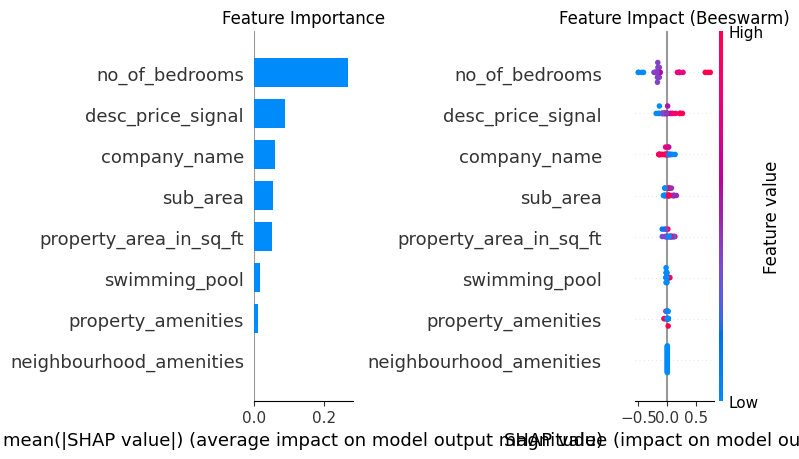

In [1071]:
# SHAP analysis:
import shap

explainer = shap.TreeExplainer(xgb_models['median'])
shap_values = explainer.shap_values(X_test_xgb)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plt.sca(axes[0])
shap.summary_plot(shap_values, X_test_xgb, plot_type='bar', show=False)
axes[0].set_title('Feature Importance')

plt.sca(axes[1])
shap.summary_plot(shap_values, X_test_xgb, show=False)
axes[1].set_title('Feature Impact (Beeswarm)')

plt.tight_layout()
plt.show()

The feature importance chart shows that no of bedrooms is by far the most important feature in moving the needle for price.

In [1072]:
# # Hyperparameter tuning (XGBoost)
# from sklearn.model_selection import GridSearchCV

# param_grid = {
#     'n_estimators': [50, 100, 200, 300],
#     'max_depth': [2, 3, 4, 5],
#     'learning_rate': [0.01, 0.05, 0.1, 0.2],
#     'min_child_weight': [1, 3, 5],
#     'subsample': [0.7, 0.8, 1.0],
# }

# xgb_grid = XGBRegressor(
#     objective='reg:quantileerror',
#     quantile_alpha=0.5,
#     random_state=42
# )

# grid_search = GridSearchCV(
#     xgb_grid,
#     param_grid,
#     cv=5,
#     scoring='neg_mean_absolute_error',
#     n_jobs=-1,
#     verbose=1
# )

# grid_search.fit(X_train_xgb, y_train)

# print(f"Best params: {grid_search.best_params_}")
# print(f"Best CV MAE: {-grid_search.best_score_:.4f}")

  ## Model Comparison

  | Metric | Linear QR + CQR | XGBoost + CQR | Winner |
  |--------|-----------------|---------------|--------|
  | Coverage (target: 90%) | 90.0% | 80.0% | LR |
  | Avg Interval Width | 46.12 lakhs | 79.78 lakhs | LR |
  | MAE | 21.27 lakhs | 26.65 lakhs | LR |
  | RMSE | 54.41 lakhs | 55.30 lakhs | LR |
  | R² | 0.5770 | 0.5631 | LR |


- XGBoost's average interval is 80 lakhs wide (vs
  LR's 46 lakhs), yet it still only covers 80% of true prices. LR gives tighter ranges and
  covers 90%.
- On limited data, XGBoost's leaf nodes end up with very few samples, making the model memorize training data rather than learning general patterns. Linear models have far fewer parameters to estimate, so they generalize
better with limited data.

# Feature Pipeline







### Saving artifacts for sklearn Pipeline

In [1076]:
import joblib
import os

# Create artifacts directory
os.makedirs('model_artifacts', exist_ok=True)

# Save quantile regression models
joblib.dump(qr_models['lower'], 'model_artifacts/qr_lower.pkl')
joblib.dump(qr_models['median'], 'model_artifacts/qr_median.pkl')
joblib.dump(qr_models['upper'], 'model_artifacts/qr_upper.pkl')

# Save preprocessing objects
joblib.dump(scaler, 'model_artifacts/scaler.pkl')
joblib.dump(te_company, 'model_artifacts/te_company.pkl')
joblib.dump(te_sub_area, 'model_artifacts/te_sub_area.pkl')

# Save TF-IDF objects
joblib.dump(tfidf, 'model_artifacts/tfidf.pkl')
joblib.dump(expensive_centroid, 'model_artifacts/expensive_centroid.pkl')
joblib.dump(cheap_centroid, 'model_artifacts/cheap_centroid.pkl')

# Save CQR correction factor
joblib.dump(q_hat, 'model_artifacts/q_hat.pkl')

print("Saved artifacts:")
for f in sorted(os.listdir('model_artifacts')):
    size = os.path.getsize(f'model_artifacts/{f}') / 1024
    print(f"  {f}: {size:.1f} KB")

Saved artifacts:
  cheap_centroid.pkl: 1.0 KB
  expensive_centroid.pkl: 1.0 KB
  q_hat.pkl: 0.1 KB
  qr_lower.pkl: 1.0 KB
  qr_median.pkl: 1.0 KB
  qr_upper.pkl: 1.0 KB
  scaler.pkl: 1.1 KB
  te_company.pkl: 2.0 KB
  te_sub_area.pkl: 1.6 KB
  tfidf.pkl: 4.4 KB
